## **Document Clustering for Reading Library**

### **Purpose**

The purpose of this pipeline is to automatically organize children's stories into meaningful category and difficulty groups, which are then served to users through the reading library feature. Since the dataset contains raw story texts without pre-assigned topic labels, unsupervised document clustering is used to discover thematic groupings from the text content itself.

Stories are grouped into three broad categories (Animals, Nature, and Daily Life) based on vocabulary patterns identified through clustering. Each story is further assigned a reading difficulty level (1-3) using the Dale-Chall Readability Score, a formula specifically designed for primary school readers that considers unfamiliar vocabulary and average sentence length. The final output is a structured JSON file organised by category and difficulty level, which can be directly imported into the frontend reading library interface.

### **Structure**
This notebook is organized into the following sections

1. Dataset loading and preprocessing (GlotStoryBook, CC-BY filtered)
2. Stopword configuration and CountVectorizer setup
3. Hard-EM and Soft-EM clustering implementation and comparison
4. Cluster keyword inspection and manual category mapping (Animals / Nature / Daily Life)
5. Dale-Chall difficulty level assignment (Level 1-3)
6. Cluster visualisation (2D SVD projection, Hard-EM vs Soft-EM comparison)
7. JSON export organised by category and difficulty level

In [1]:
pip install textstat

In [2]:
import json
import numpy as np
import pandas as pd
import textstat
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt

EPS = 1e-12

# Computes log sum exp to prevent overflow
def log_sum_exp(x):
    c = np.max(x, axis=1, keepdims=True)
    return c + np.log(np.sum(np.exp(x - c), axis=1, keepdims=True) + EPS)

# Calculates the average log-likelihood of the documents under the current EM model
def log_likelihood(X, Mu, Psi):
    log_like = (X @ np.log(Mu.T + EPS)).astype(np.float64)
    log_post = log_like + np.log(Psi + EPS)
    N = X.shape[0]
    return float(np.sum(log_sum_exp(log_post))) / N

In [3]:
# Each document is assigned to exactly one cluster during the E-step
class HardEM:
    def __init__(self, K=4, tau_max=100, epsilon=1e-6, alpha=1e-2, random_state=42):
        self.K = K
        self.tau_max = tau_max    # Maximum number of EM iterations
        self.epsilon = epsilon    # Convergence threshold
        self.alpha = alpha
        self.random_state = random_state
        self.rng = np.random.default_rng(random_state)

    def fit(self, X, verbose=False):
        # N number of documents, V vocabulary size
        N, V = X.shape
        # Probability of cluster k
        self.Psi_hat_ = np.ones(self.K) / self.K
        # Probability of word v in cluster k
        self.Mu_hat_ = self.rng.dirichlet(np.ones(V), size=self.K)
        ll_old = None
        min_iterations = 3

        for t in range(self.tau_max):
            # E-step: calculate the log-probability of each document belonging to each cluster
            log_like = X @ np.log(self.Mu_hat_.T + EPS)
            log_post = log_like + np.log(self.Psi_hat_ + EPS)
            z = np.argmax(log_post, axis=1) # Hard assignment

            # M-step: count how many documents are assigned to each cluster
            Nk = np.bincount(z, minlength=self.K).astype(float)
            self.Psi_hat_ = Nk / N

            # Prepare a new word distribution matrix for all clusters
            Mu_new = np.zeros((self.K, V), dtype=float)
            corpus_counts = np.asarray(X.sum(axis=0)).ravel() + self.alpha

            for k in range(self.K):
                if Nk[k] > 0:
                    # If the cluster has assigned documents, sum their word counts
                    row_sum = X[z == k, :].sum(axis=0)
                    Mu_new[k, :] = np.asarray(row_sum).ravel()
                else:
                    # If no documents are assigned to this cluster, reinitialize it
                    Mu_new[k, :] = self.rng.dirichlet(corpus_counts)

            Mu_new += self.alpha
            Mu_new /= Mu_new.sum(axis=1, keepdims=True)
            self.Mu_hat_ = Mu_new
            # Compute the current average log-likelihood of the model
            ll_new = log_likelihood(X, self.Mu_hat_, self.Psi_hat_)
            if verbose:
                print(f"  Iteration {t+1} ")
            if ll_old is not None:
                rel_improve = (ll_new - ll_old) / (abs(ll_old) + EPS)
                if (t + 1) >= min_iterations and rel_improve < self.epsilon:
                    print(f"  Converged at iteration {t+1}")
                    break

            # Store the current likelihood for the next iteration
            ll_old = ll_new
        return self

    def predict_proba(self, x):
        # Calculate log posterior scores for each cluster
        log_like = x @ np.log(self.Mu_hat_.T + EPS)
        log_post = log_like + np.log(self.Psi_hat_ + EPS)

        # Convert log posterior scores into normalized probabilities
        c = np.max(log_post, axis=1, keepdims=True)
        r = np.exp(log_post - c)
        r /= r.sum(axis=1, keepdims=True)
        return r

    def predict(self, x):
        # Assign each document to the cluster with the highest posterior score
        log_like = x @ np.log(self.Mu_hat_.T + EPS)
        log_post = log_like + np.log(self.Psi_hat_ + EPS)
        return np.argmax(log_post, axis=1)

In [4]:
# Each document can partially belong to multiple clusters
class SoftEM:
    def __init__(self, K=4, tau_max=100, epsilon=1e-6, alpha=1e-2, random_state=42):
        self.K = K
        self.tau_max = tau_max
        self.epsilon = epsilon
        self.alpha = alpha
        self.random_state = random_state
        self.rng = np.random.default_rng(random_state)

    def fit(self, X, verbose=False):
        N, V = X.shape
        # Initialize cluster prior probabilities equally
        self.Psi_hat_ = np.ones(self.K) / self.K
        self.Mu_hat_ = self.rng.dirichlet(np.ones(V), size=self.K)
        ll_old = None
        min_iterations = 3

        for t in range(self.tau_max):
            # E-step: calculate the log-probability of each document under each cluster
            log_like = X @ np.log(self.Mu_hat_.T + EPS)
            log_post = log_like + np.log(self.Psi_hat_ + EPS)

            # Stabilize the exponentiation step by subtracting the largest log score
            c = np.max(log_post, axis=1, keepdims=True)
            r = np.exp(log_post - c)
            r /= r.sum(axis=1, keepdims=True)

            # M-step: calculate the effective number of documents assigned to each cluster
            Nk = r.sum(axis=0)
            self.Psi_hat_ = Nk / N

            # Update word distributions using responsibility-weighted word counts
            Mu_new = (r.T @ X)
            Mu_new = np.asarray(Mu_new) + self.alpha
            Mu_new /= Mu_new.sum(axis=1, keepdims=True)
            self.Mu_hat_ = Mu_new
            ll_new = log_likelihood(X, self.Mu_hat_, self.Psi_hat_)
            if verbose:
                print(f"  Iteration {t+1} ")
            if ll_old is not None:
                rel_improve = (ll_new - ll_old) / (abs(ll_old) + EPS)
                if (t + 1) >= min_iterations and rel_improve < self.epsilon:
                    print(f"  Converged at iteration {t+1}")
                    break
            ll_old = ll_new
        return self

    def predict_proba(self, x):
        # Calculate log posterior scores for each cluster
        log_like = x @ np.log(self.Mu_hat_.T + EPS)
        log_post = log_like + np.log(self.Psi_hat_ + EPS)

        # Convert log posterior scores into normalized cluster probabilities
        c = np.max(log_post, axis=1, keepdims=True)
        r = np.exp(log_post - c)
        r /= r.sum(axis=1, keepdims=True)
        return r

    def predict(self, x):
        # Assign each document to the cluster with the highest predicted probability
        return np.argmax(self.predict_proba(x), axis=1)

In [5]:
df = pd.read_csv("GlotStoryBook.csv")
# Keep only English rows and remove rows where the story text is missing
df_en = df[df['Language'] == 'en'].dropna(subset=['Text'])

# Combine sentence-level or segment-level rows into one complete story per Parallel ID
stories = (
    df_en
    .sort_values('Text Number')
    .groupby('Parallel ID')
    .agg({
        'Text': lambda x: ' '.join(x.astype(str)),
        'License': 'first',
        'Source': 'first'
    })
    .reset_index()
)

# Count the number of words in each combined story
stories['word_count'] = stories['Text'].apply(lambda x: len(x.split()))
stories = stories[
    (stories['License'] == 'CC-BY') &
    (stories['word_count'] >= 50)
].copy().reset_index(drop=True)
print(f"Usable Story: {len(stories)}")

Usable Story: 665


In [6]:
# Add story-specific stopwords that are frequent but not useful for clustering
custom_stopwords = [
    'said', 'went', 'came', 'like', 'day', 'little', 'old',
    'big', 'away', 'looked', 'got', 'one', 'two', 'time',
    'know', 'think', 'just', 'good', 'long', 'back',
    'did', 'asked', 'home', 'mother', 'saw', 'came',
    'house', 'come', 'want', 'make', 'tree', 'man',
    'people', 'children', 'friends', 'father', 'called'
]
# Combine default English stopwords with custom stopwords
base_vec = CountVectorizer(stop_words='english')
base_sw = list(base_vec.get_stop_words())

# Convert stories into a word-count matrix for clustering
cv = CountVectorizer(
    lowercase=True,
    stop_words=base_sw + custom_stopwords,
    min_df=3,
    max_features=1000
)

# Create the document-term matrix and extract vocabulary terms
X_counts = cv.fit_transform(stories['Text'])
X_dense = X_counts.toarray().astype(np.float64)
vocab = cv.get_feature_names_out()
print(f"Vocabulary size: {len(vocab)}")
print(f"Document-term matrix shape: {X_dense.shape}")

Vocabulary size: 1000
Document-term matrix shape: (665, 1000)


In [7]:
K = 8
# Hard EM
print("  Hard EM")
hard_em = HardEM(K=K, tau_max=150, epsilon=1e-6, alpha=1e-2, random_state=42)
hard_em.fit(X_dense, verbose=True)
hard_clusters = hard_em.predict(X_dense)

# Soft EM
print("\n  Soft EM")
soft_em = SoftEM(K=K, tau_max=150, epsilon=1e-6, alpha=1e-2, random_state=42)
soft_em.fit(X_dense, verbose=True)
soft_clusters = soft_em.predict(X_dense)

  Hard EM
  Iteration 1 
  Iteration 2 
  Iteration 3 
  Iteration 4 
  Iteration 5 
  Iteration 6 
  Converged at iteration 6

  Soft EM
  Iteration 1 
  Iteration 2 
  Iteration 3 
  Iteration 4 
  Iteration 5 
  Iteration 6 
  Iteration 7 
  Iteration 8 
  Iteration 9 
  Iteration 10 
  Iteration 11 
  Iteration 12 
  Iteration 13 
  Iteration 14 
  Iteration 15 
  Converged at iteration 15


In [8]:
# HardEM keywords
print("HardEM Cluster keywords")
for k in range(K):
    mask = hard_clusters == k
    top_idx = hard_em.Mu_hat_[k].argsort()[-10:][::-1]
    top_words = [vocab[i] for i in top_idx]
    print(f"Cluster {k:2d} ({mask.sum():3d} stories): {', '.join(top_words)}")

# SoftEM keywords
print("\n SoftEM Cluster keywords")
for k in range(K):
    mask = soft_clusters == k
    top_idx = soft_em.Mu_hat_[k].argsort()[-10:][::-1]
    top_words = [vocab[i] for i in top_idx]
    print(f"Cluster {k:2d} ({mask.sum():3d} stories): {', '.join(top_words)}")


HardEM Cluster keywords
Cluster  0 ( 50 stories): king, bird, village, trees, eat, leaves, men, water, fish, elephant
Cluster  1 ( 65 stories): boy, la, tum, ti, water, oh, horse, green, gave, need
Cluster  2 ( 71 stories): elephant, birds, fly, things, don, night, look, legs, brother, hand
Cluster  3 ( 93 stories): baby, don, village, girl, ran, look, heard, woman, took, tortoise
Cluster  4 ( 93 stories): hare, night, hyena, thought, started, friend, told, help, sky, school
Cluster  5 ( 58 stories): mom, bear, happy, girl, parents, boy, blue, loved, water, gave
Cluster  6 (135 stories): lion, school, help, king, village, ran, morning, eat, food, friend
Cluster  7 (100 stories): school, fish, started, water, play, going, sheela, new, trees, thought

 SoftEM Cluster keywords
Cluster  0 ( 50 stories): king, bird, village, eat, trees, men, water, leaves, elephant, fish
Cluster  1 ( 57 stories): boy, la, tum, ti, water, oh, horse, green, gave, need
Cluster  2 ( 80 stories): elephant, look,

In [9]:
# Manually assign readable category labels based on the top HardEM keywords
# Each cluster is mapped to a broader story category for the reading library
CLUSTER_LABEL = {
    0: 'NATURE',
    1: 'NATURE',
    2: 'ANIMALS',
    3: 'ANIMALS',
    4: 'DAILY_LIFE',
    5: 'DAILY_LIFE',
    6: 'ANIMALS',
    7: 'DAILY_LIFE',
}

stories['cluster'] = hard_clusters
stories['category'] = stories['cluster'].map(CLUSTER_LABEL)
stories_final = stories[stories['category'].notna()].copy().reset_index(drop=True)

# Print how many stories are included in each final category
print("\nCategory distribution based on HardEM:")
category_counts = stories_final['category'].value_counts()

for category, count in category_counts.items():
    print(f"- {category}: {count} stories")

# Print the total number of stories kept after category mapping
print(f"\nTotal usable stories: {len(stories_final)} stories")


Category distribution based on HardEM:
- ANIMALS: 299 stories
- DAILY_LIFE: 251 stories
- NATURE: 115 stories

Total usable stories: 665 stories


In [10]:
# This score is used as a simple readability-based difficulty estimate
stories_final['dale_chall'] = stories_final['Text'].apply(
    textstat.dale_chall_readability_score
)

# Convert Dale-Chall readability scores into three difficulty levels
def assign_level(score):
    if score <= 6.0:   return 1
    elif score <= 8.0: return 2
    else:              return 3

# Assign a difficulty level to each story
stories_final['difficulty'] = stories_final['dale_chall'].apply(assign_level)

print("Difficulty distribution")
difficulty_counts = stories_final['difficulty'].value_counts().sort_index()
for level, count in difficulty_counts.items():
    print(f"Level {level:<2} | {count:>3} stories")

category_difficulty = pd.crosstab(
    stories_final['category'],
    stories_final['difficulty']
)

# Make sure all three level columns exist, even if one level has no stories
for level in [1, 2, 3]:
    if level not in category_difficulty.columns:
        category_difficulty[level] = 0

print()
category_difficulty = category_difficulty[[1, 2, 3]]
# Rename columns for clearer output
category_difficulty.columns = ['Level 1', 'Level 2', 'Level 3']
category_difficulty.index.name = None
print(category_difficulty.to_string())

Difficulty distribution
Level 1  |  86 stories
Level 2  | 438 stories
Level 3  | 141 stories

            Level 1  Level 2  Level 3
ANIMALS          47      195       57
DAILY_LIFE       28      163       60
NATURE           11       80       24


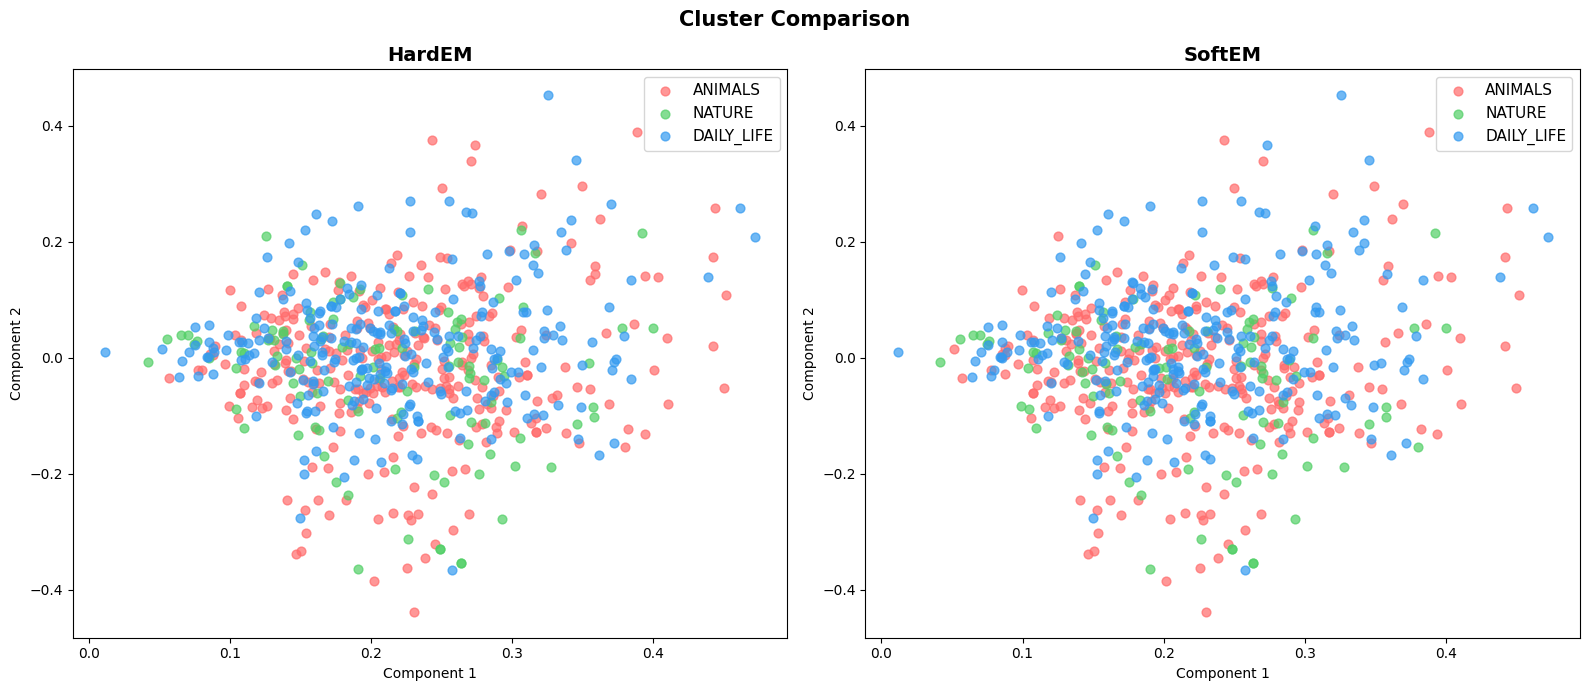

In [11]:
# Normalize the document-term matrix
Xn = normalize(X_dense, norm='l2')
# Reduce the high-dimensional document vectors to 2 dimensions for plotting
svd_2d = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd_2d.fit_transform(Xn)
colors = {'ANIMALS': '#FF6B6B', 'NATURE': '#51CF66', 'DAILY_LIFE': '#339AF0'}
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Visualize the HardEM category assignments
for cat, color in colors.items():
    mask = stories_final['category'] == cat
    # Plot the 2D points for this category
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=cat, alpha=0.7, s=40)
# Format the HardEM plot
axes[0].set_title('HardEM', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Component 1')
axes[0].set_ylabel('Component 2')
axes[0].legend(fontsize=11)

# Create a SoftEM version of the story table with predicted clusters
stories_soft = stories.copy()
stories_soft['cluster'] = soft_clusters
stories_soft['category'] = stories_soft['cluster'].map(CLUSTER_LABEL)
stories_soft = stories_soft[stories_soft['category'].notna()]

# Visualize the SoftEM category assignments
for cat, color in colors.items():
    mask = stories_soft['category'] == cat
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=cat, alpha=0.7, s=40)

# Format the SoftEM plot
axes[1].set_title('SoftEM', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Component 1')
axes[1].set_ylabel('Component 2')
axes[1].legend(fontsize=11)

plt.suptitle('Cluster Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Create the final nested JSON structure for the reading library
result = {}

# Export stories for each final category
for category in ['ANIMALS', 'NATURE', 'DAILY_LIFE']:
    result[category] = {}

    # Store stories separately for each difficulty level
    for level in [1, 2, 3]:
        # Select stories that match the current category and difficulty level
        mask = (
            (stories_final['category'] == category) &
            (stories_final['difficulty'] == level)
        )
        # Parallel ID is renamed to id for a cleaner frontend data structure
        subset = stories_final[mask][[
            'Parallel ID', 'Text', 'word_count', 'dale_chall', 'Source'
        ]].rename(columns={'Parallel ID': 'id'})
        # Convert the selected stories into a list of dictionaries
        result[category][f'level_{level}'] = subset.to_dict(orient='records')

# Save the final story library as a JSON file
with open('stories_final.json', 'w', encoding='utf-8') as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

print("Saved: stories_final.json")
print("Final JSON structure")
for cat in result:
    for lv in result[cat]:
        print(f"{cat} / {lv}: {len(result[cat][lv])} stories")

Saved: stories_final.json
Final JSON structure
ANIMALS / level_1: 47 stories
ANIMALS / level_2: 195 stories
ANIMALS / level_3: 57 stories
NATURE / level_1: 11 stories
NATURE / level_2: 80 stories
NATURE / level_3: 24 stories
DAILY_LIFE / level_1: 28 stories
DAILY_LIFE / level_2: 163 stories
DAILY_LIFE / level_3: 60 stories
